In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load metrics from experiments

In [2]:
fluxnet_results = pd.read_csv("results/fluxnet_runs_metrics_15epochs.csv")
resmlp_results = pd.read_csv("results/resmlp_runs_metrics_15epochs.csv")

## Print FluxNet metrics

In [3]:
print("FluxNet on Train (scaled):")
print(f"Mean train MAE: {fluxnet_results['train_mae'].mean():.5f}")
print(f"Std  train MAE: {fluxnet_results['train_mae'].std():.5f}")
print("")
print(f"Mean train RMSE: {fluxnet_results['train_rmse'].mean():.5f}")
print(f"Std  train RMSE: {fluxnet_results['train_rmse'].std():.5f}")

FluxNet on Train (scaled):
Mean train MAE: 0.04818
Std  train MAE: 0.00540

Mean train RMSE: 0.09254
Std  train RMSE: 0.00642


In [4]:
print("FluxNet on Test:")
print(f"Mean test  MAE: {fluxnet_results['test_mae'].mean():.5f}")
print(f"Std  test  MAE: {fluxnet_results['test_mae'].std():.5f}")
print("")
print(f"Mean test  RMSE: {fluxnet_results['test_rmse'].mean():.5f}")
print(f"Std  test  RMSE: {fluxnet_results['test_rmse'].std():.5f}")

FluxNet on Test:
Mean test  MAE: 0.05829
Std  test  MAE: 0.00421

Mean test  RMSE: 0.10079
Std  test  RMSE: 0.00478


## Print ResMLP metrics

In [5]:
print("ResMLP on Train:")
print(f"Mean train  MAE: {resmlp_results['train_mae'].mean():.5f}")
print(f"Std  train  MAE: {resmlp_results['train_mae'].std():.5f}")
print("")
print(f"Mean train  RMSE: {resmlp_results['train_rmse'].mean():.5f}")
print(f"Std  train  RMSE: {resmlp_results['train_rmse'].std():.5f}")

ResMLP on Train:
Mean train  MAE: 0.05027
Std  train  MAE: 0.01017

Mean train  RMSE: 0.09743
Std  train  RMSE: 0.01402


In [6]:
print("ResMLP on Test:")
print(f"Mean test  MAE: {resmlp_results['test_mae'].mean():.5f}")
print(f"Std  test  MAE: {resmlp_results['test_mae'].std():.5f}")
print("")
print(f"Mean test  RMSE: {resmlp_results['test_rmse'].mean():.5f}")
print(f"Std  test  RMSE: {resmlp_results['test_rmse'].std():.5f}")

ResMLP on Test:
Mean test  MAE: 0.06349
Std  test  MAE: 0.00812

Mean test  RMSE: 0.11418
Std  test  RMSE: 0.00883


# Barchart

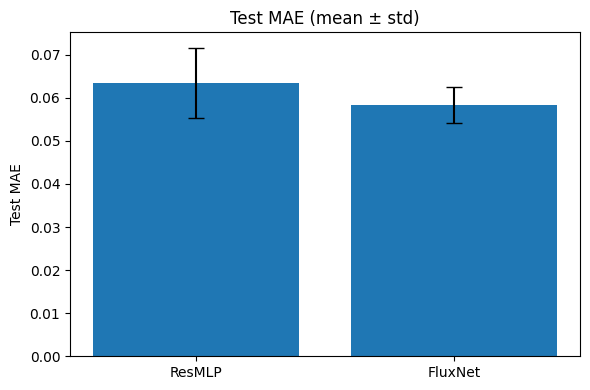

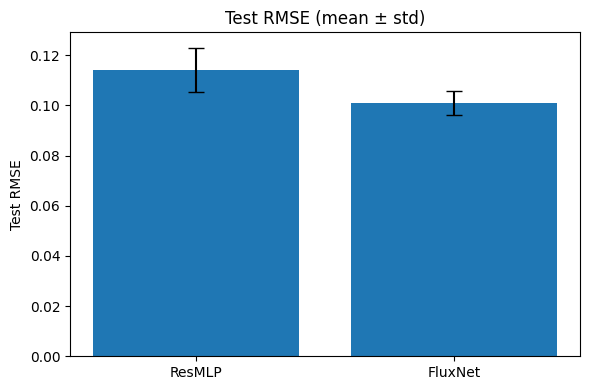

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ---- compute means + stds ----
models = ["ResMLP", "FluxNet"]

mae_mean = [resmlp_results["test_mae"].mean(),  fluxnet_results["test_mae"].mean()]
mae_std  = [resmlp_results["test_mae"].std(),   fluxnet_results["test_mae"].std()]

rmse_mean = [resmlp_results["test_rmse"].mean(), fluxnet_results["test_rmse"].mean()]
rmse_std  = [resmlp_results["test_rmse"].std(),  fluxnet_results["test_rmse"].std()]

# ---- bar chart: MAE ----
x = np.arange(len(models))
plt.figure(figsize = (6, 4))
plt.bar(x, mae_mean, yerr = mae_std, capsize = 6)
plt.xticks(x, models)
plt.ylabel("Test MAE")
plt.title("Test MAE (mean ± std)")
plt.tight_layout()
plt.show()

# ---- bar chart: RMSE ----
plt.figure(figsize = (6, 4))
plt.bar(x, rmse_mean, yerr = rmse_std, capsize = 6)
plt.xticks(x, models)
plt.ylabel("Test RMSE")
plt.title("Test RMSE (mean ± std)")
plt.tight_layout()
plt.show()


In [8]:
scale = 100_000

mae_mean = [resmlp_results["test_mae"].mean() * scale, fluxnet_results["test_mae"].mean() * scale]
mae_std  = [resmlp_results["test_mae"].std()  * scale, fluxnet_results["test_mae"].std()  * scale]

rmse_mean = [resmlp_results["test_rmse"].mean() * scale, fluxnet_results["test_rmse"].mean() * scale]
rmse_std  = [resmlp_results["test_rmse"].std()  * scale, fluxnet_results["test_rmse"].std()  * scale]

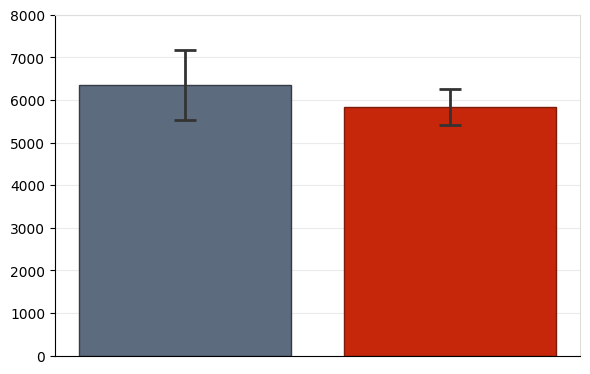

In [10]:
colors = ["#5d6b7f", "#C6260A"]
edgecolors = ["#363c44", "#7C1D0C"]

x = np.arange(len(models))
plt.figure(figsize = (6, 4))
plt.grid(axis = 'y', alpha = 0.3, color = "#bdbdbd", zorder = 1)
plt.bar(x, mae_mean, yerr = mae_std, capsize = 8, color = colors, edgecolor = edgecolors, zorder = 2, 
        error_kw={'elinewidth': 2.0, 'capthick': 2.0, 'ecolor': '#333333'})
ax = plt.gca()
ax.spines['top'].set_color('#dddddd')
ax.spines['right'].set_color('#dddddd')
plt.ylim(0, 8000)
plt.tight_layout()
plt.xticks([])
plt.savefig('figures/flux_reconstruction_mae.png', format = 'png', dpi = 300, bbox_inches = 'tight')
plt.show()

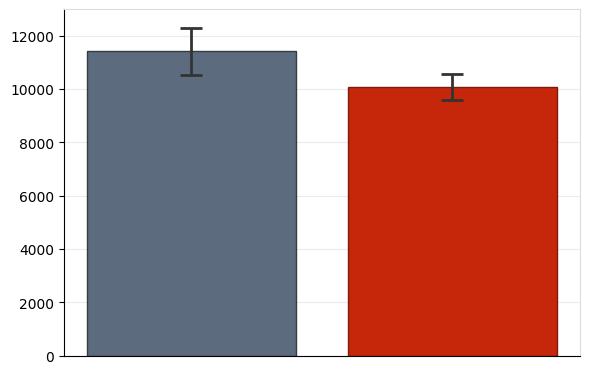

In [13]:
colors = ["#5d6b7f", "#C6260A"]
edgecolors = ["#363c44", "#7C1D0C"]

x = np.arange(len(models))
plt.figure(figsize = (6, 4))
plt.grid(axis = 'y', alpha = 0.3, color = "#bdbdbd", zorder = 1)
plt.bar(x, rmse_mean, yerr = rmse_std, capsize = 8, color = colors, edgecolor = edgecolors, zorder = 2, 
        error_kw={'elinewidth': 2.0, 'capthick': 2.0, 'ecolor': '#333333'})
ax = plt.gca()
ax.spines['top'].set_color('#dddddd')
ax.spines['right'].set_color('#dddddd')
plt.ylim(0, 13000)
plt.tight_layout()
plt.xticks([])
plt.savefig('figures/flux_reconstruction_rmse.png', format = 'png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Convergences

In [9]:
fluxnet_conv = pd.read_csv("trained_models/fluxnet_trained_15epochs_loss_convergence.csv")
resmlp_conv = pd.read_csv("trained_models/resmlp_trained_15epochs_loss_convergence.csv")

# add epoch column
fluxnet_conv["epoch"] = range(1, len(fluxnet_conv) + 1)
resmlp_conv["epoch"]  = range(1, len(resmlp_conv) + 1)

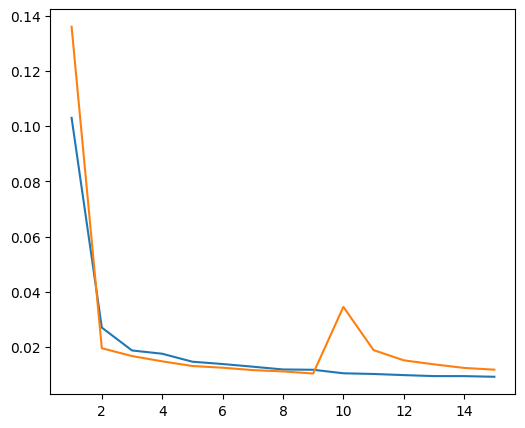

In [10]:
plt.figure(figsize = (6, 5))
plt.plot(fluxnet_conv["epoch"], fluxnet_conv["train_loss"], label = "FluxNet Train Loss")
plt.plot(resmlp_conv["epoch"], resmlp_conv["train_loss"], label = "ResMLP Train Loss")
plt.show()